# Crude Oil Supply and Demand Analysis

## Data Processing

This analysis focuses on crude oil supply/demand dynamics:

1. Use NEWSAPIORG_KEY from .env to get Headlines from newsapi.org

    1.1. Source filter: Multiple financial news sources (Bloomberg, Reuters, WSJ, etc.)

    1.2. Keyword filter: Enhanced keywords covering supply, demand, and market events

    1.3. Create a DataFrame with ONLY columns: Date/Time, Headline, Source

    1.4. Create Visualisation for source and time distribution of the articles

2. Create Manual Topics: **oil_supply** (production, exports, OPEC) and **oil_demand** (consumption, imports, economic factors)

3. Use FinBERT to do the following:

    3.1 Classify each headline into one of the manual topics using weighted keyword scoring

    3.2 Calculate a sentiment score and confidence for each headline categorised in each topic

    3.3 Output a DataFrame with following columns: Date/Time, Headline, Source, Topic, Sentiment, Confidence

    3.4. Create visualisation for: Sentiment distribution per topic, headline distribution in each topic, confidence level for each topic

4. Analyze relationship between sentiment and WTI price changes

In [272]:
# Core imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# API imports
from newsapi import NewsApiClient
import requests

# Set plotting style
plt.style.use('ggplot')

# Load environment variables
load_dotenv()

print("✓ Imports loaded successfully")


✓ Imports loaded successfully


---
## Part 1: NewsAPI.org
Getting crude oil headlines from newsapi.org


In [273]:
# Initialize NewsAPI.org client
api_key_org = os.getenv('NEWSAPIORG_KEY')
newsapi = NewsApiClient(api_key=api_key_org)

# Define search parameters - optimized for crude oil supply/demand
# Strategic keywords under 500 char limit - covers production, demand, and market events
ENERGY_KEYWORDS = (
    '"crude oil" OR "oil price" OR petroleum OR WTI OR Brent OR '
    'OPEC OR "oil production" OR "oil supply" OR "oil demand" OR '
    '"oil market" OR "oil inventory" OR refinery OR refineries OR '
    '"energy prices" OR "oil barrel" OR "oil exports" OR "oil imports" OR '
    '"shale oil" OR drilling OR "energy crisis" OR "oil sanctions"'
)
SOURCES = 'al-jazeera-english, associated-press, australian-financial-review, bbc-news, bloomberg, cbs-news, cnn, fox-news, google-news, msnbc, reuters, the-wall-street-journal, the-washington-post'

print(f"API Key loaded: {'✓' if api_key_org else '✗'}")
print(f"\nKeywords ({len(ENERGY_KEYWORDS)} chars): {ENERGY_KEYWORDS}")
print(f"\nSources: {SOURCES}")


API Key loaded: ✓

Keywords (310 chars): "crude oil" OR "oil price" OR petroleum OR WTI OR Brent OR OPEC OR "oil production" OR "oil supply" OR "oil demand" OR "oil market" OR "oil inventory" OR refinery OR refineries OR "energy prices" OR "oil barrel" OR "oil exports" OR "oil imports" OR "shale oil" OR drilling OR "energy crisis" OR "oil sanctions"

Sources: al-jazeera-english, associated-press, australian-financial-review, bbc-news, bloomberg, cbs-news, cnn, fox-news, google-news, msnbc, reuters, the-wall-street-journal, the-washington-post


In [274]:
# Fetch articles from NewsAPI.org in weekly increments
print("Fetching articles from NewsAPI.org in weekly increments...")

try:
    # Calculate date ranges for the past 4 weeks
    today = datetime.now()
    all_articles = []
    
    for week in range(4):
        # Calculate 'to' date (end of week period)
        to_date = today - timedelta(weeks=week)
        # Calculate 'from' date (start of week period)
        from_date = to_date - timedelta(weeks=1)
        
        # Format dates for API (ISO 8601 format)
        from_str = from_date.strftime('%Y-%m-%d')
        to_str = to_date.strftime('%Y-%m-%d')
        
        print(f"\nWeek {week + 1}: {from_str} to {to_str}")
        
        # Fetch articles for this week
        articles_week = newsapi.get_everything(
            q=ENERGY_KEYWORDS,
            sources=SOURCES,
            language='en',
            sort_by='publishedAt',
            from_param=from_str,
            to=to_str,
            page_size=100
        )
        
        print(f"  Total results available: {articles_week['totalResults']}")
        print(f"  Articles retrieved: {len(articles_week['articles'])}")
        
        # Add articles to list
        all_articles.extend(articles_week['articles'])
    
    # Convert all articles to DataFrame
    df_org = pd.DataFrame(all_articles)
    
    # Remove duplicates based on URL (in case of overlapping data)
    if not df_org.empty and 'url' in df_org.columns:
        initial_count = len(df_org)
        df_org = df_org.drop_duplicates(subset=['url'], keep='first')
        duplicates_removed = initial_count - len(df_org)
        if duplicates_removed > 0:
            print(f"\n  Removed {duplicates_removed} duplicate articles")
    
    # Process source column
    if not df_org.empty and 'source' in df_org.columns:
        df_org['source_id'] = df_org['source'].apply(lambda x: x['id'] if x else None)
        df_org['source_name'] = df_org['source'].apply(lambda x: x['name'] if x else None)
    
    # Parse dates
    if not df_org.empty and 'publishedAt' in df_org.columns:
        df_org['date'] = pd.to_datetime(df_org['publishedAt']).dt.date
    
    print(f"\n✓ DataFrame created with shape: {df_org.shape}")
    print(f"✓ Total unique articles retrieved: {len(df_org)}")
    
except Exception as e:
    print(f"✗ Error: {e}")
    df_org = pd.DataFrame()


Fetching articles from NewsAPI.org in weekly increments...

Week 1: 2025-10-01 to 2025-10-08
  Total results available: 26
  Articles retrieved: 26

Week 2: 2025-09-24 to 2025-10-01
  Total results available: 35
  Articles retrieved: 35

Week 3: 2025-09-17 to 2025-09-24
  Total results available: 25
  Articles retrieved: 25

Week 4: 2025-09-10 to 2025-09-17
  Total results available: 37
  Articles retrieved: 37

  Removed 14 duplicate articles

✓ DataFrame created with shape: (109, 11)
✓ Total unique articles retrieved: 109


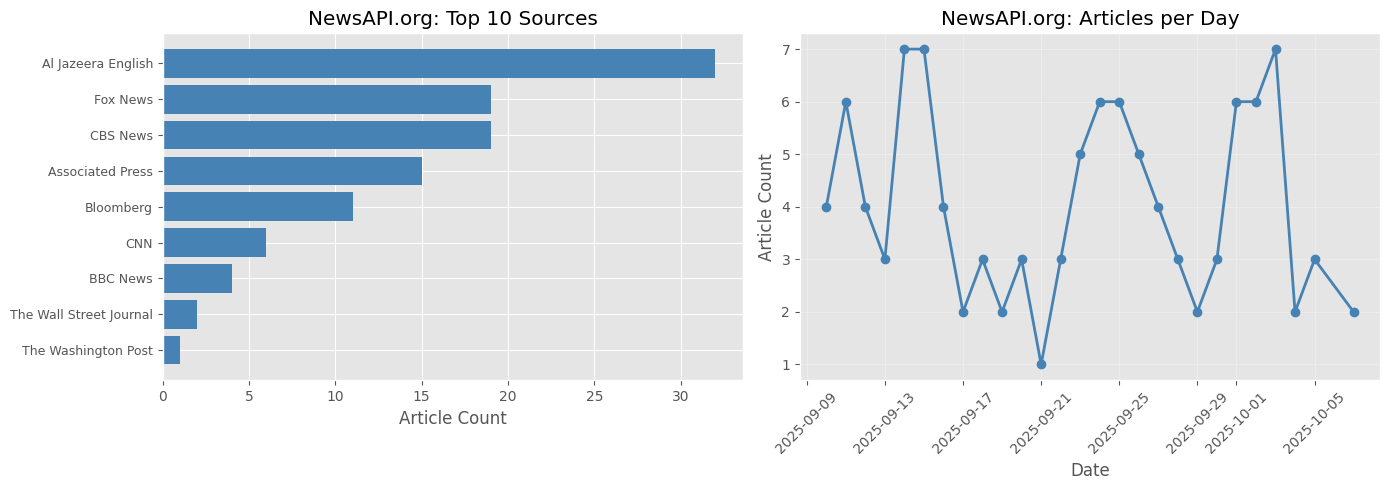

In [275]:
# Visualize NewsAPI.org data
if not df_org.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Source distribution
    source_counts = df_org['source_name'].value_counts().head(10)
    axes[0].barh(range(len(source_counts)), source_counts.values, color='steelblue')
    axes[0].set_yticks(range(len(source_counts)))
    axes[0].set_yticklabels(source_counts.index, fontsize=9)
    axes[0].set_xlabel('Article Count')
    axes[0].set_title('NewsAPI.org: Top 10 Sources')
    axes[0].invert_yaxis()
    
    # Temporal distribution
    articles_per_day = df_org.groupby('date').size().sort_index()
    axes[1].plot(articles_per_day.index, articles_per_day.values, 
                 marker='o', linewidth=2, color='steelblue')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Article Count')
    axes[1].set_title('NewsAPI.org: Articles per Day')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize")


---
## Part 2: FinBERT Topic Classification & Sentiment Analysis
Classify headlines into oil production/demand and analyze sentiment

In [276]:
# FinBERT Setup
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm import tqdm

print("Loading FinBERT model...")
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
finbert_model.to(device)

print(f"✓ FinBERT loaded on {device}")


Loading FinBERT model...
✓ FinBERT loaded on cpu


In [277]:
# Define refined topics for crude oil supply/demand classification
TOPICS = {
    'oil_supply': {
        # High confidence supply keywords (weight: 3)
        'strong': [
            'opec decision', 'opec meeting', 'opec+', 'production cut', 'production quota',
            'output cut', 'output increase', 'supply cut', 'drilling activity',
            'rig count', 'shale production', 'oil extraction', 'production capacity'
        ],
        # Medium confidence supply keywords (weight: 2)
        'medium': [
            'oil production', 'crude production', 'oil output', 'oil supply',
            'crude supply', 'oil exports', 'crude exports', 'export ban',
            'opec', 'drilling', 'shale oil', 'offshore', 'oil field',
            'oil reserves', 'oil wells', 'producers', 'production'
        ],
        # Weak supply indicators (weight: 1)
        'weak': [
            'supply', 'output', 'export', 'inventory', 'storage', 'refinery',
            'pipeline', 'infrastructure'
        ]
    },
    'oil_demand': {
        # High confidence demand keywords (weight: 3)
        'strong': [
            'demand growth', 'demand decline', 'demand forecast', 'demand outlook',
            'consumption growth', 'consumption decline', 'fuel demand',
            'gasoline demand', 'diesel demand', 'china demand', 'asia demand'
        ],
        # Medium confidence demand keywords (weight: 2)
        'medium': [
            'oil demand', 'crude demand', 'oil consumption', 'fuel consumption',
            'oil imports', 'crude imports', 'import growth', 'import decline',
            'energy demand', 'demand', 'consumption', 'economic growth',
            'recession', 'recovery'
        ],
        # Weak demand indicators (weight: 1)
        'weak': [
            'import', 'buyers', 'purchasing', 'appetite', 'usage'
        ]
    }
}

def classify_topic(headline):
    """
    Enhanced topic classification with weighted scoring
    Returns 'oil_supply' or 'oil_demand' based on context
    """
    headline_lower = headline.lower()
    
    supply_score = 0
    demand_score = 0
    
    # Strong keywords (weight: 3)
    for keyword in TOPICS['oil_supply']['strong']:
        if keyword in headline_lower:
            supply_score += 3
    
    for keyword in TOPICS['oil_demand']['strong']:
        if keyword in headline_lower:
            demand_score += 3
    
    # Medium keywords (weight: 2)
    for keyword in TOPICS['oil_supply']['medium']:
        if keyword in headline_lower:
            supply_score += 2
    
    for keyword in TOPICS['oil_demand']['medium']:
        if keyword in headline_lower:
            demand_score += 2
    
    # Weak keywords (weight: 1)
    for keyword in TOPICS['oil_supply']['weak']:
        if keyword in headline_lower:
            supply_score += 1
    
    for keyword in TOPICS['oil_demand']['weak']:
        if keyword in headline_lower:
            demand_score += 1
    
    # Special case handling for ambiguous terms
    # If headline mentions both price AND supply/demand context
    if 'price' in headline_lower:
        # Price drops often linked to oversupply or weak demand
        if any(term in headline_lower for term in ['fall', 'drop', 'decline', 'lower', 'down']):
            if any(term in headline_lower for term in ['surplus', 'glut', 'oversupply']):
                supply_score += 2
            elif any(term in headline_lower for term in ['weak', 'slump', 'slowdown']):
                demand_score += 2
        # Price rises often linked to supply concerns or strong demand
        elif any(term in headline_lower for term in ['rise', 'surge', 'jump', 'climb', 'higher', 'up']):
            if any(term in headline_lower for term in ['shortage', 'tight', 'constraint']):
                supply_score += 2
            elif any(term in headline_lower for term in ['strong', 'robust', 'growth']):
                demand_score += 2
    
    # OPEC is primarily supply-focused
    if 'opec' in headline_lower:
        supply_score += 1
    
    # Return classification
    if supply_score > demand_score:
        return 'oil_supply'
    elif demand_score > supply_score:
        return 'oil_demand'
    else:
        # Tie-breaker: default to supply if OPEC mentioned, otherwise demand
        if 'opec' in headline_lower or 'production' in headline_lower:
            return 'oil_supply'
        else:
            return 'oil_demand'

print("✓ Enhanced topic classification ready")
print(f"Topics: oil_supply, oil_demand")
print(f"Classification uses weighted scoring (strong=3, medium=2, weak=1)")


✓ Enhanced topic classification ready
Topics: oil_supply, oil_demand
Classification uses weighted scoring (strong=3, medium=2, weak=1)


In [278]:
def analyze_sentiment(text, tokenizer, model, device):
    """
    Analyze sentiment using FinBERT
    Returns sentiment score from -1 (negative) to +1 (positive) and confidence
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    # FinBERT outputs: [positive, negative, neutral]
    scores = predictions.cpu().numpy()[0]
    positive_score = float(scores[0])
    negative_score = float(scores[1])
    
    # Sentiment score: positive - negative (range -1 to 1)
    sentiment_score = positive_score - negative_score
    
    # Confidence: max probability
    confidence = float(np.max(scores))
    
    return sentiment_score, confidence

print("✓ Sentiment analysis function ready")


✓ Sentiment analysis function ready


In [279]:
# Process headlines: topic classification + sentiment analysis
print("Processing headlines...")

results = []
for idx, row in tqdm(df_org.iterrows(), total=len(df_org), desc="Analyzing"):
    headline = row['title']
    
    # Topic classification
    topic = classify_topic(headline)
    
    # Sentiment analysis (score from -1 to 1)
    sentiment_score, confidence = analyze_sentiment(headline, tokenizer, finbert_model, device)
    
    results.append({
        'date_time': row['publishedAt'],
        'headline': headline,
        'source': row['source_name'],
        'topic': topic,
        'sentiment': sentiment_score,
        'confidence': confidence
    })

# Create results DataFrame
df_results = pd.DataFrame(results)

print(f"\n✓ Processed {len(df_results)} headlines")
print(f"\nColumns: {list(df_results.columns)}")
print(f"\nTopic distribution:")
print(df_results['topic'].value_counts())

# Display sample of each topic
print(f"\nSample oil_supply headlines:")
display(df_results[df_results['topic'] == 'oil_supply'].head(3))

print(f"\nSample oil_demand headlines:")
display(df_results[df_results['topic'] == 'oil_demand'].head(3))


Processing headlines...


Analyzing: 100%|██████████| 109/109 [00:06<00:00, 16.79it/s]


✓ Processed 109 headlines

Columns: ['date_time', 'headline', 'source', 'topic', 'sentiment', 'confidence']

Topic distribution:
topic
oil_demand    91
oil_supply    18
Name: count, dtype: int64

Sample oil_supply headlines:


,date_time,headline,source,topic,sentiment,confidence
7,2025-10-03T23:20:00Z,Massive fire breaks out after explosion at Che...,CBS News,oil_supply,-0.758838,0.787792
8,2025-10-03T20:35:00Z,Crews put out fire at Southern California Chev...,CBS News,oil_supply,-0.771232,0.819947
11,2025-10-03T06:18:25Z,Massive fire erupts at Chevron refinery near L...,Associated Press,oil_supply,-0.882411,0.895121



Sample oil_demand headlines:


,date_time,headline,source,topic,sentiment,confidence
0,2025-10-07T11:10:31Z,Nayara energy revives fuel sales to Brazil and...,Bloomberg,oil_demand,0.921166,0.934567
1,2025-10-07T08:42:30Z,Shell signals energy trading rebound in boost ...,Bloomberg,oil_demand,0.716057,0.774167
2,2025-10-05T20:02:28Z,"DAVID MARCUS: 20 years after ‘The Office,’ ‘Th...",Fox News,oil_demand,-0.030663,0.875654


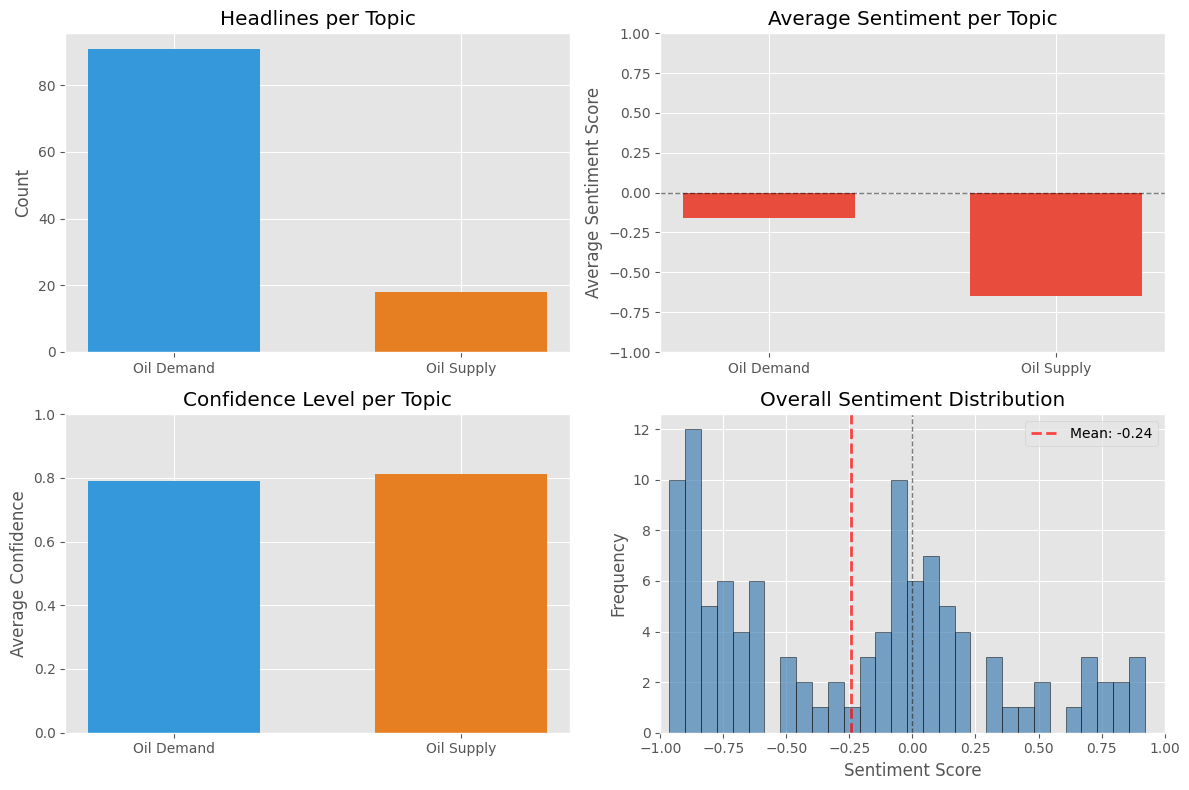

In [280]:
# Visualizations - Crude Oil Production & Demand Focus
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Headline distribution per topic
topic_counts = df_results['topic'].value_counts().sort_index()
axes[0, 0].bar(range(len(topic_counts)), topic_counts.values, 
               color=['#3498db', '#e67e22'], width=0.6)
axes[0, 0].set_xticks(range(len(topic_counts)))
axes[0, 0].set_xticklabels([t.replace('_', ' ').title() for t in topic_counts.index], rotation=0)
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Headlines per Topic')

# 2. Average sentiment per topic
topic_sentiment = df_results.groupby('topic')['sentiment'].mean().sort_index()
colors_sent = ['#e74c3c' if x < 0 else '#2ecc71' for x in topic_sentiment.values]
axes[0, 1].bar(range(len(topic_sentiment)), topic_sentiment.values, 
               color=colors_sent, width=0.6)
axes[0, 1].set_xticks(range(len(topic_sentiment)))
axes[0, 1].set_xticklabels([t.replace('_', ' ').title() for t in topic_sentiment.index], rotation=0)
axes[0, 1].set_ylabel('Average Sentiment Score')
axes[0, 1].set_title('Average Sentiment per Topic')
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 1].set_ylim([-1, 1])

# 3. Confidence level per topic
topic_confidence = df_results.groupby('topic')['confidence'].mean().sort_index()
axes[1, 0].bar(range(len(topic_confidence)), topic_confidence.values, 
               color=['#3498db', '#e67e22'], width=0.6)
axes[1, 0].set_xticks(range(len(topic_confidence)))
axes[1, 0].set_xticklabels([t.replace('_', ' ').title() for t in topic_confidence.index], rotation=0)
axes[1, 0].set_ylabel('Average Confidence')
axes[1, 0].set_title('Confidence Level per Topic')
axes[1, 0].set_ylim([0, 1])

# 4. Overall sentiment distribution (histogram)
axes[1, 1].hist(df_results['sentiment'], bins=30, color='steelblue', 
                edgecolor='black', alpha=0.7, linewidth=0.5)
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].axvline(df_results['sentiment'].mean(), color='red', linestyle='--', 
                   linewidth=2, alpha=0.7, label=f"Mean: {df_results['sentiment'].mean():.2f}")
axes[1, 1].set_xlabel('Sentiment Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Overall Sentiment Distribution')
axes[1, 1].set_xlim([-1, 1])
axes[1, 1].legend()

plt.tight_layout()
plt.show()


---
## Part 3: WTI Price Analysis
Analyze relationship between sentiment scores and WTI crude oil price changes

In [281]:
# Load WTI price data
wti_path = 'WTI.csv'
df_wti = pd.read_csv(wti_path)

# Convert Unix timestamp to datetime
df_wti['datetime'] = pd.to_datetime(df_wti['time'], unit='s')

# Sort by datetime
df_wti = df_wti.sort_values('datetime').reset_index(drop=True)

print(f"✓ WTI data loaded: {len(df_wti)} records")
print(f"Date range: {df_wti['datetime'].min()} to {df_wti['datetime'].max()}")
print(f"\nWTI DataFrame shape: {df_wti.shape}")
df_wti.head()


✓ WTI data loaded: 1267 records
Date range: 2025-07-18 17:00:00 to 2025-10-03 20:00:00

WTI DataFrame shape: (1267, 4)


,time,close,Volume,datetime
0,1752858000,65.99,6541,2025-07-18 17:00:00
1,1752861600,66.16,9155,2025-07-18 18:00:00
2,1752865200,66.06,4790,2025-07-18 19:00:00
3,1752868800,66.03,2455,2025-07-18 20:00:00
4,1753048800,66.26,1714,2025-07-20 22:00:00


In [282]:
def get_price_change(headline_time, wti_df):
    """
    Get WTI price change in the hour following the headline
    ALWAYS rounds UP to next available price to avoid look-ahead bias
    Returns price change or None if data not available
    """
    headline_dt = pd.to_datetime(headline_time)
    
    # Convert to timezone-naive if timezone-aware (to match WTI data)
    if headline_dt.tz is not None:
        headline_dt = headline_dt.tz_convert('UTC').tz_localize(None)
    
    # Find first price AT OR AFTER headline time (round UP to avoid look-ahead bias)
    future_prices_at_headline = wti_df[wti_df['datetime'] >= headline_dt]
    
    if len(future_prices_at_headline) == 0:
        return None
    
    # Check if first available price is within reasonable time (2 hours max)
    first_price_time = future_prices_at_headline.iloc[0]['datetime']
    if (first_price_time - headline_dt) > timedelta(hours=2):
        return None
    
    price_at_headline = future_prices_at_headline.iloc[0]['close']
    
    # Find price one hour after the first available price
    one_hour_later = first_price_time + timedelta(hours=1)
    future_prices_1h = wti_df[wti_df['datetime'] >= one_hour_later]
    
    if len(future_prices_1h) == 0:
        return None
    
    price_one_hour_later = future_prices_1h.iloc[0]['close']
    
    # Calculate price change
    price_change = price_one_hour_later - price_at_headline
    
    return price_change

print("✓ Price change function defined (no look-ahead bias)")


✓ Price change function defined (no look-ahead bias)


In [283]:
# Calculate price changes for each headline
print("Calculating price changes...")

df_results['price_change'] = df_results['date_time'].apply(
    lambda x: get_price_change(x, df_wti)
)

# Filter out rows where price change couldn't be calculated
df_analysis = df_results.dropna(subset=['price_change']).copy()

print(f"\n✓ Price changes calculated")
print(f"Headlines with matching WTI data: {len(df_analysis)} / {len(df_results)}")
print(f"\nSample data:")
df_analysis[['date_time', 'headline', 'topic', 'sentiment', 'price_change']].head()


Calculating price changes...



✓ Price changes calculated
Headlines with matching WTI data: 77 / 109

Sample data:


,date_time,headline,topic,sentiment,price_change
9,2025-10-03T10:19:12Z,India’s billionaire family offices face deeper...,oil_demand,-0.796084,0.16
10,2025-10-03T07:29:52Z,How much of Europe’s oil and gas still comes f...,oil_demand,0.018280,-0.54
11,2025-10-03T06:18:25Z,Massive fire erupts at Chevron refinery near L...,oil_supply,-0.882411,0.41
12,2025-10-03T05:33:40Z,Fire at Chevron refinery sends massive flames ...,oil_supply,-0.452319,-0.16
13,2025-10-03T04:48:00Z,Large fire erupts at Los Angeles-area Chevron ...,oil_supply,-0.897828,0.12


In [284]:
# Multiple Linear Regression Analysis with Sentiment, Confidence, and Source
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("Multiple Linear Regression Analysis by Topic")
print("=" * 70)
print("Predictors: Sentiment, Confidence, Source (dummy variables)")
print("=" * 70)

regression_results = {}
models = {}

for topic in df_analysis['topic'].unique():
    topic_data = df_analysis[df_analysis['topic'] == topic].copy()
    
    if len(topic_data) < 5:  # Need sufficient data for multiple regression
        print(f"\n{topic.replace('_', ' ').title()}: Insufficient data (n={len(topic_data)})")
        continue
    
    # Create dummy variables for source
    source_dummies = pd.get_dummies(topic_data['source'], prefix='source', drop_first=True)
    
    # Prepare features: sentiment, confidence, and source dummies
    X_features = pd.concat([
        topic_data[['sentiment', 'confidence']].reset_index(drop=True),
        source_dummies.reset_index(drop=True)
    ], axis=1)
    
    y = topic_data['price_change'].values
    
    # Fit multiple linear regression model
    model = LinearRegression()
    model.fit(X_features, y)
    
    # Make predictions
    y_pred = model.predict(X_features)
    
    # Calculate metrics
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Store results
    regression_results[topic] = {
        'model': model,
        'r_squared': r2,
        'rmse': rmse,
        'n': len(topic_data),
        'features': list(X_features.columns),
        'coefficients': dict(zip(X_features.columns, model.coef_)),
        'intercept': model.intercept_,
        'predictions': y_pred,
        'actual': y
    }
    
    # Store model for later use
    models[topic] = {
        'model': model,
        'features': list(X_features.columns)
    }
    
    print(f"\n{topic.replace('_', ' ').title()}:")
    print(f"  n = {len(topic_data)}")
    print(f"  R² = {r2:.4f}")
    print(f"  RMSE = {rmse:.4f} $/barrel")
    print(f"\n  Coefficients:")
    print(f"    Intercept: {model.intercept_:.4f}")
    print(f"    Sentiment: {regression_results[topic]['coefficients']['sentiment']:.4f}")
    print(f"    Confidence: {regression_results[topic]['coefficients']['confidence']:.4f}")
    
    # Show source dummy coefficients if any
    source_coefs = {k: v for k, v in regression_results[topic]['coefficients'].items() if k.startswith('source_')}
    if source_coefs:
        print(f"    Source dummies:")
        for source, coef in list(source_coefs.items())[:5]:  # Show top 5
            print(f"      {source}: {coef:.4f}")
        if len(source_coefs) > 5:
            print(f"      ... and {len(source_coefs) - 5} more sources")

print("\n" + "=" * 70)


Multiple Linear Regression Analysis by Topic
Predictors: Sentiment, Confidence, Source (dummy variables)

Oil Demand:
  n = 67
  R² = 0.1464
  RMSE = 0.2273 $/barrel

  Coefficients:
    Intercept: -0.0406
    Sentiment: -0.0143
    Confidence: 0.0081
    Source dummies:
      source_Associated Press: 0.2384
      source_BBC News: 0.1411
      source_Bloomberg: -0.0476
      source_CBS News: 0.1879
      source_CNN: 0.2371
      ... and 3 more sources

Oil Supply:
  n = 10
  R² = 0.6861
  RMSE = 0.1114 $/barrel

  Coefficients:
    Intercept: 0.5780
    Sentiment: 0.0693
    Confidence: -0.6762
    Source dummies:
      source_Associated Press: 0.2493
      source_Bloomberg: 0.0531
      source_CBS News: 0.2198
      source_CNN: 0.2307
      source_Fox News: -0.3738



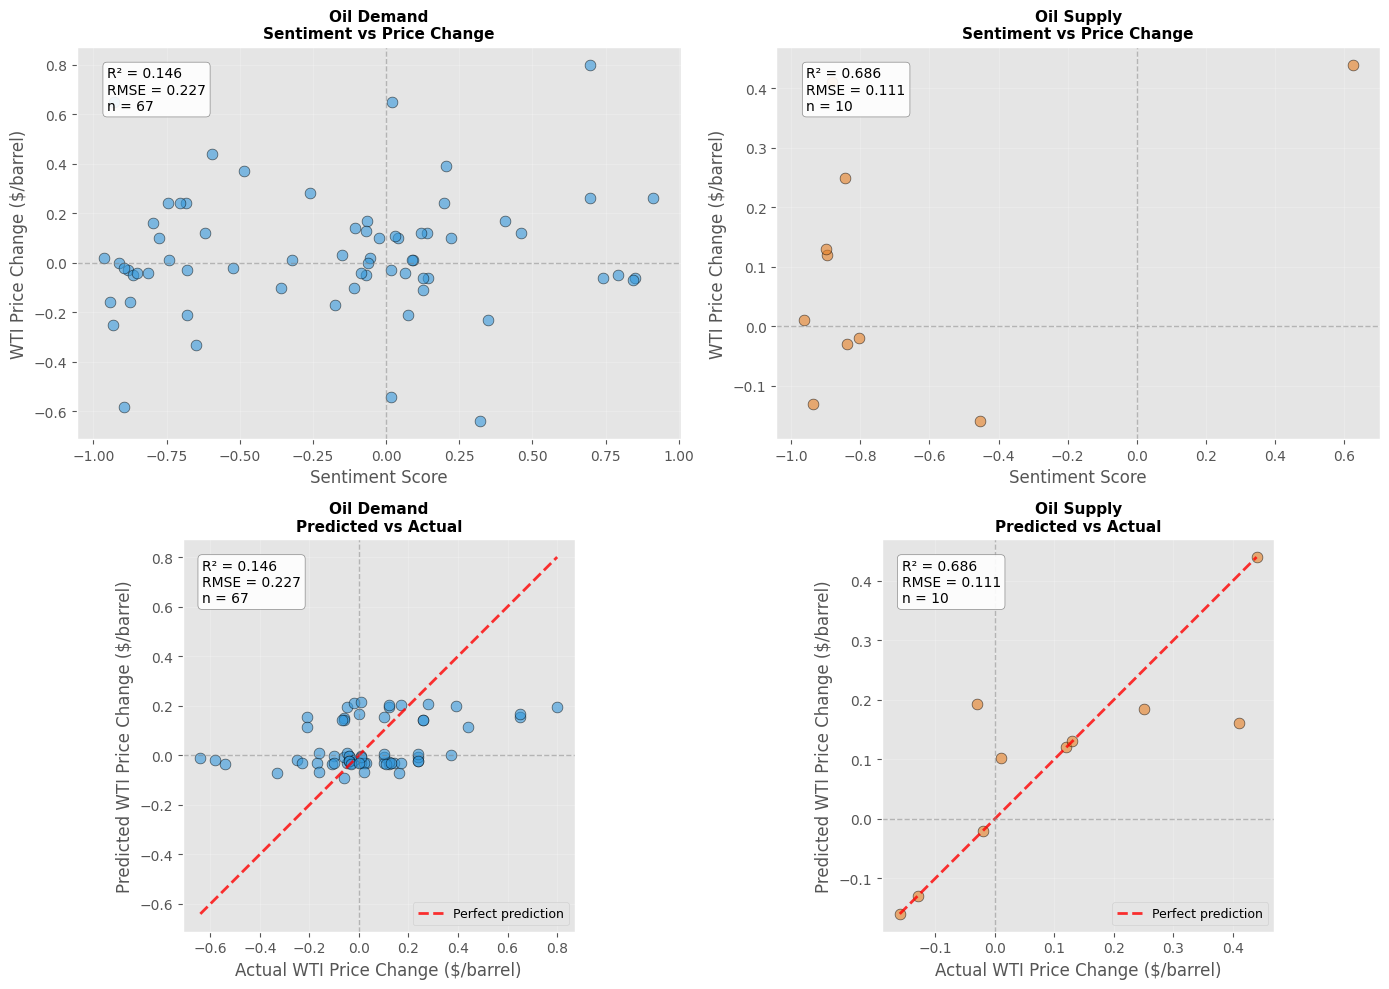

In [285]:
# Create 2x2 subplot visualization: Sentiment Scatter & Predicted vs Actual
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

topics = ['oil_demand', 'oil_supply']
colors = ['#3498db', '#e67e22']

# Top row: Sentiment vs Price Change scatter plots
for idx, topic in enumerate(topics):
    ax = axes[0, idx]
    topic_data = df_analysis[df_analysis['topic'] == topic]
    
    if len(topic_data) < 5:
        ax.text(0.5, 0.5, f'Insufficient data\n(n={len(topic_data)})', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(topic.replace('_', ' ').title(), fontsize=12, weight='bold')
        ax.set_xlabel('Sentiment Score')
        ax.set_ylabel('WTI Price Change ($/barrel)')
        continue
    
    X = topic_data['sentiment'].values
    y = topic_data['price_change'].values
    
    # Scatter plot
    ax.scatter(X, y, alpha=0.6, s=60, color=colors[idx], edgecolors='black', linewidth=0.5)
    
    # Add regression statistics
    if topic in regression_results:
        r_squared = regression_results[topic]['r_squared']
        rmse = regression_results[topic]['rmse']
        n = regression_results[topic]['n']
        
        stats_text = f'R² = {r_squared:.3f}\nRMSE = {rmse:.3f}\nn = {n}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.set_title(f'{topic.replace("_", " ").title()}\nSentiment vs Price Change', 
                 fontsize=11, weight='bold')
    ax.set_xlabel('Sentiment Score')
    ax.set_ylabel('WTI Price Change ($/barrel)')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.grid(True, alpha=0.3, linewidth=0.5)

# Bottom row: Predicted vs Actual Price Changes
for idx, topic in enumerate(topics):
    ax = axes[1, idx]
    
    if topic not in regression_results:
        ax.text(0.5, 0.5, 'Model not available', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{topic.replace("_", " ").title()}\nPredicted vs Actual', 
                     fontsize=11, weight='bold')
        continue
    
    # Get predictions and actual values
    y_pred = regression_results[topic]['predictions']
    y_actual = regression_results[topic]['actual']
    
    # Scatter plot: predicted vs actual
    ax.scatter(y_actual, y_pred, alpha=0.6, s=60, color=colors[idx], 
               edgecolors='black', linewidth=0.5)
    
    # Add perfect prediction line (y=x)
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', 
            linewidth=2, alpha=0.8, label='Perfect prediction')
    
    # Add statistics
    r_squared = regression_results[topic]['r_squared']
    rmse = regression_results[topic]['rmse']
    n = regression_results[topic]['n']
    
    stats_text = f'R² = {r_squared:.3f}\nRMSE = {rmse:.3f}\nn = {n}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.set_title(f'{topic.replace("_", " ").title()}\nPredicted vs Actual', 
                 fontsize=11, weight='bold')
    ax.set_xlabel('Actual WTI Price Change ($/barrel)')
    ax.set_ylabel('Predicted WTI Price Change ($/barrel)')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(loc='best', fontsize=9)
    
    # Make axes equal for better comparison
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


In [286]:
# Summary statistics for Crude Oil Analysis
print("=" * 70)
print("CRUDE OIL SUPPLY & DEMAND ANALYSIS - SUMMARY")
print("=" * 70)

print(f"\nData Overview:")
print(f"  Total headlines analyzed: {len(df_results)}")
print(f"  Headlines with WTI price data: {len(df_analysis)}")

print(f"\nTopic Breakdown:")
topics_sorted = ['oil_supply', 'oil_demand']
for topic in topics_sorted:
    count = len(df_analysis[df_analysis['topic'] == topic])
    avg_sent = df_analysis[df_analysis['topic'] == topic]['sentiment'].mean()
    print(f"  {topic.replace('_', ' ').title()}: {count} headlines (avg sentiment: {avg_sent:.3f})")

print(f"\nSentiment Statistics:")
print(f"  Range: [{df_analysis['sentiment'].min():.3f}, {df_analysis['sentiment'].max():.3f}]")
print(f"  Mean: {df_analysis['sentiment'].mean():.3f}")
print(f"  Std Dev: {df_analysis['sentiment'].std():.3f}")

print(f"\nWTI Price Change Statistics:")
print(f"  Range: [{df_analysis['price_change'].min():.3f}, {df_analysis['price_change'].max():.3f}] $/barrel")
print(f"  Mean: {df_analysis['price_change'].mean():.3f} $/barrel")
print(f"  Std Dev: {df_analysis['price_change'].std():.3f} $/barrel")

# Overall correlation (all topics combined)
overall_corr = df_analysis[['sentiment', 'price_change']].corr().iloc[0, 1]
print(f"\nOverall Correlation:")
print(f"  Sentiment vs Price Change: {overall_corr:.4f}")

print("\n" + "=" * 70)


CRUDE OIL SUPPLY & DEMAND ANALYSIS - SUMMARY

Data Overview:
  Total headlines analyzed: 109
  Headlines with WTI price data: 77

Topic Breakdown:
  Oil Supply: 10 headlines (avg sentiment: -0.689)
  Oil Demand: 67 headlines (avg sentiment: -0.187)

Sentiment Statistics:
  Range: [-0.964, 0.913]
  Mean: -0.252
  Std Dev: 0.552

WTI Price Change Statistics:
  Range: [-0.640, 0.800] $/barrel
  Mean: 0.044 $/barrel
  Std Dev: 0.243 $/barrel

Overall Correlation:
  Sentiment vs Price Change: 0.0995



---
## Part 4: Alternative Analysis - 4-Hour Price Change
Analyze relationship using 4-hour price movements instead of 1-hour


In [287]:
def get_price_change_4h(headline_time, wti_df):
    """
    Get WTI price change in the 4 hours following the headline
    ALWAYS rounds UP to next available price to avoid look-ahead bias
    Returns price change or None if data not available
    """
    headline_dt = pd.to_datetime(headline_time)
    
    # Convert to timezone-naive if timezone-aware (to match WTI data)
    if headline_dt.tz is not None:
        headline_dt = headline_dt.tz_convert('UTC').tz_localize(None)
    
    # Find first price AT OR AFTER headline time (round UP to avoid look-ahead bias)
    future_prices_at_headline = wti_df[wti_df['datetime'] >= headline_dt]
    
    if len(future_prices_at_headline) == 0:
        return None
    
    # Check if first available price is within reasonable time (2 hours max)
    first_price_time = future_prices_at_headline.iloc[0]['datetime']
    if (first_price_time - headline_dt) > timedelta(hours=2):
        return None
    
    price_at_headline = future_prices_at_headline.iloc[0]['close']
    
    # Find price four hours after the first available price
    four_hours_later = first_price_time + timedelta(hours=4)
    future_prices_4h = wti_df[wti_df['datetime'] >= four_hours_later]
    
    if len(future_prices_4h) == 0:
        return None
    
    price_four_hours_later = future_prices_4h.iloc[0]['close']
    
    # Calculate price change
    price_change = price_four_hours_later - price_at_headline
    
    return price_change

print("✓ 4-hour price change function defined (no look-ahead bias)")


✓ 4-hour price change function defined (no look-ahead bias)


In [288]:
# Calculate 4-hour price changes for each headline
print("Calculating 4-hour price changes...")

df_results['price_change_4h'] = df_results['date_time'].apply(
    lambda x: get_price_change_4h(x, df_wti)
)

# Filter out rows where price change couldn't be calculated
df_analysis_4h = df_results.dropna(subset=['price_change_4h']).copy()

print(f"\n✓ 4-hour price changes calculated")
print(f"Headlines with matching WTI data: {len(df_analysis_4h)} / {len(df_results)}")
print(f"\nComparison with 1-hour analysis:")
print(f"  1-hour dataset: {len(df_analysis)} headlines")
print(f"  4-hour dataset: {len(df_analysis_4h)} headlines")
print(f"\nSample data:")
df_analysis_4h[['date_time', 'headline', 'topic', 'sentiment', 'price_change_4h']].head()


Calculating 4-hour price changes...

✓ 4-hour price changes calculated
Headlines with matching WTI data: 77 / 109

Comparison with 1-hour analysis:
  1-hour dataset: 77 headlines
  4-hour dataset: 77 headlines

Sample data:


,date_time,headline,topic,sentiment,price_change_4h
9,2025-10-03T10:19:12Z,India’s billionaire family offices face deeper...,oil_demand,-0.796084,0.35
10,2025-10-03T07:29:52Z,How much of Europe’s oil and gas still comes f...,oil_demand,0.018280,-0.51
11,2025-10-03T06:18:25Z,Massive fire erupts at Chevron refinery near L...,oil_supply,-0.882411,-0.26
12,2025-10-03T05:33:40Z,Fire at Chevron refinery sends massive flames ...,oil_supply,-0.452319,-0.38
13,2025-10-03T04:48:00Z,Large fire erupts at Los Angeles-area Chevron ...,oil_supply,-0.897828,-0.17


In [289]:
# Multiple Linear Regression Analysis with 4-hour price changes
print("Multiple Linear Regression Analysis by Topic (4-Hour Price Change)")
print("=" * 70)
print("Predictors: Sentiment, Confidence, Source (dummy variables)")
print("=" * 70)

regression_results_4h = {}
models_4h = {}

for topic in df_analysis_4h['topic'].unique():
    topic_data = df_analysis_4h[df_analysis_4h['topic'] == topic].copy()
    
    if len(topic_data) < 5:  # Need sufficient data for multiple regression
        print(f"\n{topic.replace('_', ' ').title()}: Insufficient data (n={len(topic_data)})")
        continue
    
    # Create dummy variables for source
    source_dummies = pd.get_dummies(topic_data['source'], prefix='source', drop_first=True)
    
    # Prepare features: sentiment, confidence, and source dummies
    X_features = pd.concat([
        topic_data[['sentiment', 'confidence']].reset_index(drop=True),
        source_dummies.reset_index(drop=True)
    ], axis=1)
    
    y = topic_data['price_change_4h'].values
    
    # Fit multiple linear regression model
    model = LinearRegression()
    model.fit(X_features, y)
    
    # Make predictions
    y_pred = model.predict(X_features)
    
    # Calculate metrics
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Store results
    regression_results_4h[topic] = {
        'model': model,
        'r_squared': r2,
        'rmse': rmse,
        'n': len(topic_data),
        'features': list(X_features.columns),
        'coefficients': dict(zip(X_features.columns, model.coef_)),
        'intercept': model.intercept_,
        'predictions': y_pred,
        'actual': y
    }
    
    # Store model for later use
    models_4h[topic] = {
        'model': model,
        'features': list(X_features.columns)
    }
    
    print(f"\n{topic.replace('_', ' ').title()}:")
    print(f"  n = {len(topic_data)}")
    print(f"  R² = {r2:.4f}")
    print(f"  RMSE = {rmse:.4f} $/barrel")
    print(f"\n  Coefficients:")
    print(f"    Intercept: {model.intercept_:.4f}")
    print(f"    Sentiment: {regression_results_4h[topic]['coefficients']['sentiment']:.4f}")
    print(f"    Confidence: {regression_results_4h[topic]['coefficients']['confidence']:.4f}")
    
    # Show source dummy coefficients if any
    source_coefs = {k: v for k, v in regression_results_4h[topic]['coefficients'].items() if k.startswith('source_')}
    if source_coefs:
        print(f"    Source dummies:")
        for source, coef in list(source_coefs.items())[:5]:  # Show top 5
            print(f"      {source}: {coef:.4f}")
        if len(source_coefs) > 5:
            print(f"      ... and {len(source_coefs) - 5} more sources")

print("\n" + "=" * 70)


Multiple Linear Regression Analysis by Topic (4-Hour Price Change)
Predictors: Sentiment, Confidence, Source (dummy variables)

Oil Demand:
  n = 67
  R² = 0.1489
  RMSE = 0.4060 $/barrel

  Coefficients:
    Intercept: 0.4775
    Sentiment: -0.1175
    Confidence: -0.6695
    Source dummies:
      source_Associated Press: -0.1281
      source_BBC News: -0.0299
      source_Bloomberg: -0.2270
      source_CBS News: 0.3981
      source_CNN: 0.2360
      ... and 3 more sources

Oil Supply:
  n = 10
  R² = 0.7558
  RMSE = 0.1836 $/barrel

  Coefficients:
    Intercept: 3.7069
    Sentiment: -0.3444
    Confidence: -4.1643
    Source dummies:
      source_Associated Press: -0.2381
      source_Bloomberg: -0.6463
      source_CBS News: -0.3953
      source_CNN: 0.3082
      source_Fox News: -2.1931



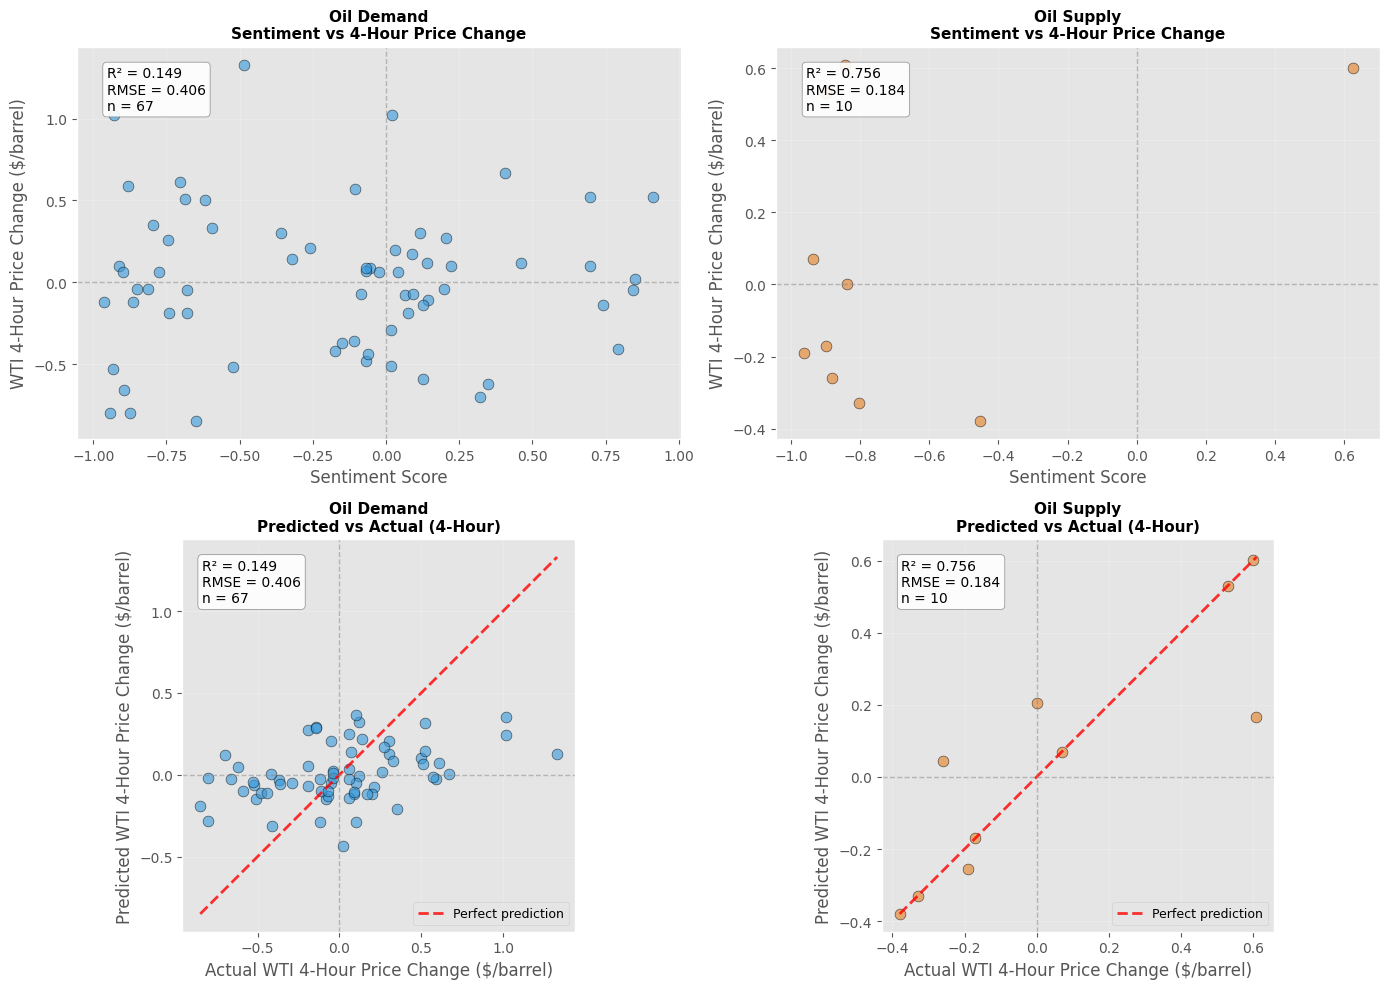

In [290]:
# Create 2x2 subplot visualization for 4-hour analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

topics = ['oil_demand', 'oil_supply']
colors = ['#3498db', '#e67e22']

# Top row: Sentiment vs 4-Hour Price Change scatter plots
for idx, topic in enumerate(topics):
    ax = axes[0, idx]
    topic_data = df_analysis_4h[df_analysis_4h['topic'] == topic]
    
    if len(topic_data) < 5:
        ax.text(0.5, 0.5, f'Insufficient data\n(n={len(topic_data)})', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(topic.replace('_', ' ').title(), fontsize=12, weight='bold')
        ax.set_xlabel('Sentiment Score')
        ax.set_ylabel('WTI 4-Hour Price Change ($/barrel)')
        continue
    
    X = topic_data['sentiment'].values
    y = topic_data['price_change_4h'].values
    
    # Scatter plot
    ax.scatter(X, y, alpha=0.6, s=60, color=colors[idx], edgecolors='black', linewidth=0.5)
    
    # Add regression statistics
    if topic in regression_results_4h:
        r_squared = regression_results_4h[topic]['r_squared']
        rmse = regression_results_4h[topic]['rmse']
        n = regression_results_4h[topic]['n']
        
        stats_text = f'R² = {r_squared:.3f}\nRMSE = {rmse:.3f}\nn = {n}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.set_title(f'{topic.replace("_", " ").title()}\nSentiment vs 4-Hour Price Change', 
                 fontsize=11, weight='bold')
    ax.set_xlabel('Sentiment Score')
    ax.set_ylabel('WTI 4-Hour Price Change ($/barrel)')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.grid(True, alpha=0.3, linewidth=0.5)

# Bottom row: Predicted vs Actual 4-Hour Price Changes
for idx, topic in enumerate(topics):
    ax = axes[1, idx]
    
    if topic not in regression_results_4h:
        ax.text(0.5, 0.5, 'Model not available', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{topic.replace("_", " ").title()}\nPredicted vs Actual', 
                     fontsize=11, weight='bold')
        continue
    
    # Get predictions and actual values
    y_pred = regression_results_4h[topic]['predictions']
    y_actual = regression_results_4h[topic]['actual']
    
    # Scatter plot: predicted vs actual
    ax.scatter(y_actual, y_pred, alpha=0.6, s=60, color=colors[idx], 
               edgecolors='black', linewidth=0.5)
    
    # Add perfect prediction line (y=x)
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', 
            linewidth=2, alpha=0.8, label='Perfect prediction')
    
    # Add statistics
    r_squared = regression_results_4h[topic]['r_squared']
    rmse = regression_results_4h[topic]['rmse']
    n = regression_results_4h[topic]['n']
    
    stats_text = f'R² = {r_squared:.3f}\nRMSE = {rmse:.3f}\nn = {n}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.set_title(f'{topic.replace("_", " ").title()}\nPredicted vs Actual (4-Hour)', 
                 fontsize=11, weight='bold')
    ax.set_xlabel('Actual WTI 4-Hour Price Change ($/barrel)')
    ax.set_ylabel('Predicted WTI 4-Hour Price Change ($/barrel)')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(loc='best', fontsize=9)
    
    # Make axes equal for better comparison
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


In [291]:
# Summary statistics for 4-Hour Analysis
print("=" * 70)
print("4-HOUR PRICE CHANGE ANALYSIS - SUMMARY")
print("=" * 70)

print(f"\nData Overview:")
print(f"  Total headlines analyzed: {len(df_results)}")
print(f"  Headlines with WTI 4-hour price data: {len(df_analysis_4h)}")

print(f"\nTopic Breakdown:")
topics_sorted = ['oil_supply', 'oil_demand']
for topic in topics_sorted:
    count = len(df_analysis_4h[df_analysis_4h['topic'] == topic])
    avg_sent = df_analysis_4h[df_analysis_4h['topic'] == topic]['sentiment'].mean()
    print(f"  {topic.replace('_', ' ').title()}: {count} headlines (avg sentiment: {avg_sent:.3f})")

print(f"\nSentiment Statistics:")
print(f"  Range: [{df_analysis_4h['sentiment'].min():.3f}, {df_analysis_4h['sentiment'].max():.3f}]")
print(f"  Mean: {df_analysis_4h['sentiment'].mean():.3f}")
print(f"  Std Dev: {df_analysis_4h['sentiment'].std():.3f}")

print(f"\nWTI 4-Hour Price Change Statistics:")
print(f"  Range: [{df_analysis_4h['price_change_4h'].min():.3f}, {df_analysis_4h['price_change_4h'].max():.3f}] $/barrel")
print(f"  Mean: {df_analysis_4h['price_change_4h'].mean():.3f} $/barrel")
print(f"  Std Dev: {df_analysis_4h['price_change_4h'].std():.3f} $/barrel")

# Overall correlation (all topics combined)
overall_corr_4h = df_analysis_4h[['sentiment', 'price_change_4h']].corr().iloc[0, 1]
print(f"\nOverall Correlation:")
print(f"  Sentiment vs 4-Hour Price Change: {overall_corr_4h:.4f}")

print("\n" + "=" * 70)


4-HOUR PRICE CHANGE ANALYSIS - SUMMARY

Data Overview:
  Total headlines analyzed: 109
  Headlines with WTI 4-hour price data: 77

Topic Breakdown:
  Oil Supply: 10 headlines (avg sentiment: -0.689)
  Oil Demand: 67 headlines (avg sentiment: -0.187)

Sentiment Statistics:
  Range: [-0.964, 0.913]
  Mean: -0.252
  Std Dev: 0.552

WTI 4-Hour Price Change Statistics:
  Range: [-0.850, 1.330] $/barrel
  Mean: 0.012 $/barrel
  Std Dev: 0.435 $/barrel

Overall Correlation:
  Sentiment vs 4-Hour Price Change: 0.0412



In [292]:
# Comparison: 1-Hour vs 4-Hour Analysis
print("=" * 70)
print("COMPARISON: 1-HOUR vs 4-HOUR PRICE CHANGE ANALYSIS")
print("=" * 70)

print("\n" + "-" * 70)
print("Dataset Sizes:")
print("-" * 70)
print(f"  1-Hour analysis:  {len(df_analysis)} headlines")
print(f"  4-Hour analysis:  {len(df_analysis_4h)} headlines")

print("\n" + "-" * 70)
print("Price Change Statistics:")
print("-" * 70)
print(f"  1-Hour price change:")
print(f"    Mean: {df_analysis['price_change'].mean():.4f} $/barrel")
print(f"    Std Dev: {df_analysis['price_change'].std():.4f} $/barrel")
print(f"    Range: [{df_analysis['price_change'].min():.3f}, {df_analysis['price_change'].max():.3f}]")

print(f"\n  4-Hour price change:")
print(f"    Mean: {df_analysis_4h['price_change_4h'].mean():.4f} $/barrel")
print(f"    Std Dev: {df_analysis_4h['price_change_4h'].std():.4f} $/barrel")
print(f"    Range: [{df_analysis_4h['price_change_4h'].min():.3f}, {df_analysis_4h['price_change_4h'].max():.3f}]")

print("\n" + "-" * 70)
print("Overall Correlation (Sentiment vs Price Change):")
print("-" * 70)
print(f"  1-Hour:  {overall_corr:.4f}")
print(f"  4-Hour:  {overall_corr_4h:.4f}")

print("\n" + "-" * 70)
print("Model Performance by Topic:")
print("-" * 70)

for topic in ['oil_supply', 'oil_demand']:
    print(f"\n  {topic.replace('_', ' ').title()}:")
    
    # 1-hour results
    if topic in regression_results:
        r2_1h = regression_results[topic]['r_squared']
        rmse_1h = regression_results[topic]['rmse']
        n_1h = regression_results[topic]['n']
        print(f"    1-Hour: R² = {r2_1h:.4f}, RMSE = {rmse_1h:.4f}, n = {n_1h}")
    else:
        print(f"    1-Hour: No model available")
    
    # 4-hour results
    if topic in regression_results_4h:
        r2_4h = regression_results_4h[topic]['r_squared']
        rmse_4h = regression_results_4h[topic]['rmse']
        n_4h = regression_results_4h[topic]['n']
        print(f"    4-Hour: R² = {r2_4h:.4f}, RMSE = {rmse_4h:.4f}, n = {n_4h}")
    else:
        print(f"    4-Hour: No model available")
    
    # Show improvement/change
    if topic in regression_results and topic in regression_results_4h:
        r2_change = r2_4h - r2_1h
        rmse_change = rmse_4h - rmse_1h
        print(f"    Change: ΔR² = {r2_change:+.4f}, ΔRMSE = {rmse_change:+.4f}")

print("\n" + "=" * 70)


COMPARISON: 1-HOUR vs 4-HOUR PRICE CHANGE ANALYSIS

----------------------------------------------------------------------
Dataset Sizes:
----------------------------------------------------------------------
  1-Hour analysis:  77 headlines
  4-Hour analysis:  77 headlines

----------------------------------------------------------------------
Price Change Statistics:
----------------------------------------------------------------------
  1-Hour price change:
    Mean: 0.0443 $/barrel
    Std Dev: 0.2431 $/barrel
    Range: [-0.640, 0.800]

  4-Hour price change:
    Mean: 0.0121 $/barrel
    Std Dev: 0.4349 $/barrel
    Range: [-0.850, 1.330]

----------------------------------------------------------------------
Overall Correlation (Sentiment vs Price Change):
----------------------------------------------------------------------
  1-Hour:  0.0995
  4-Hour:  0.0412

----------------------------------------------------------------------
Model Performance by Topic:
------------------